This notebook allows the user to manually outline the desert area that we want to exclude from the "non-vegetated pixels" surface type for some analyses. The Cropland Data Layer (CDL) classifies desert areas as "barren," which is a desirable surface type for analyses and is behaves similarly to roads. So, these surface types are combined in previous code because they are both non-cropland. When we took the CDL and performed "ungeocoding" to convert it to radar coordinates, we combined developed pixels (urban areas) and barren (open fields, desert, etc.) into the "roadarray.r4" mask file. Now, we want to separate the desert from the rest of the NVG pixels, so we must do this manually. 
<br>
<br>
Use the "earthscope_insar" conda environment as the Python kernel for this and all subsequent notebooks.
***

In [8]:
# import necessary files 
# import os,sys
# import glob
from osgeo import gdal
# from datetime import datetime 
import numpy as np
import matplotlib.pyplot as plt
# from scipy.ndimage import gaussian_filter
# import matplotlib.colors as mcolors
%matplotlib  widget

from matplotlib.path import Path
# # not sure if I'll end up actually using shapely
from shapely.geometry import Polygon
# import shapely.plotting

In [2]:
# load in the roadarray that we "ungeocoded" (converted from geographic to radar coordinates to match the SAR data grid)
f1 = gdal.Open('roadarray.r4', gdal.GA_ReadOnly)
roads = f1.ReadAsArray()
dy,dx = np.shape(roads)

In [3]:
# make a function that takes the point you clicked and adds it to an array of coordinates 

def on_click(event):
    global pts
    if event.button == 1:
        pts.append((event.xdata, event.ydata))
        plt.plot(event.xdata, event.ydata, 'r.')
        plt.draw()


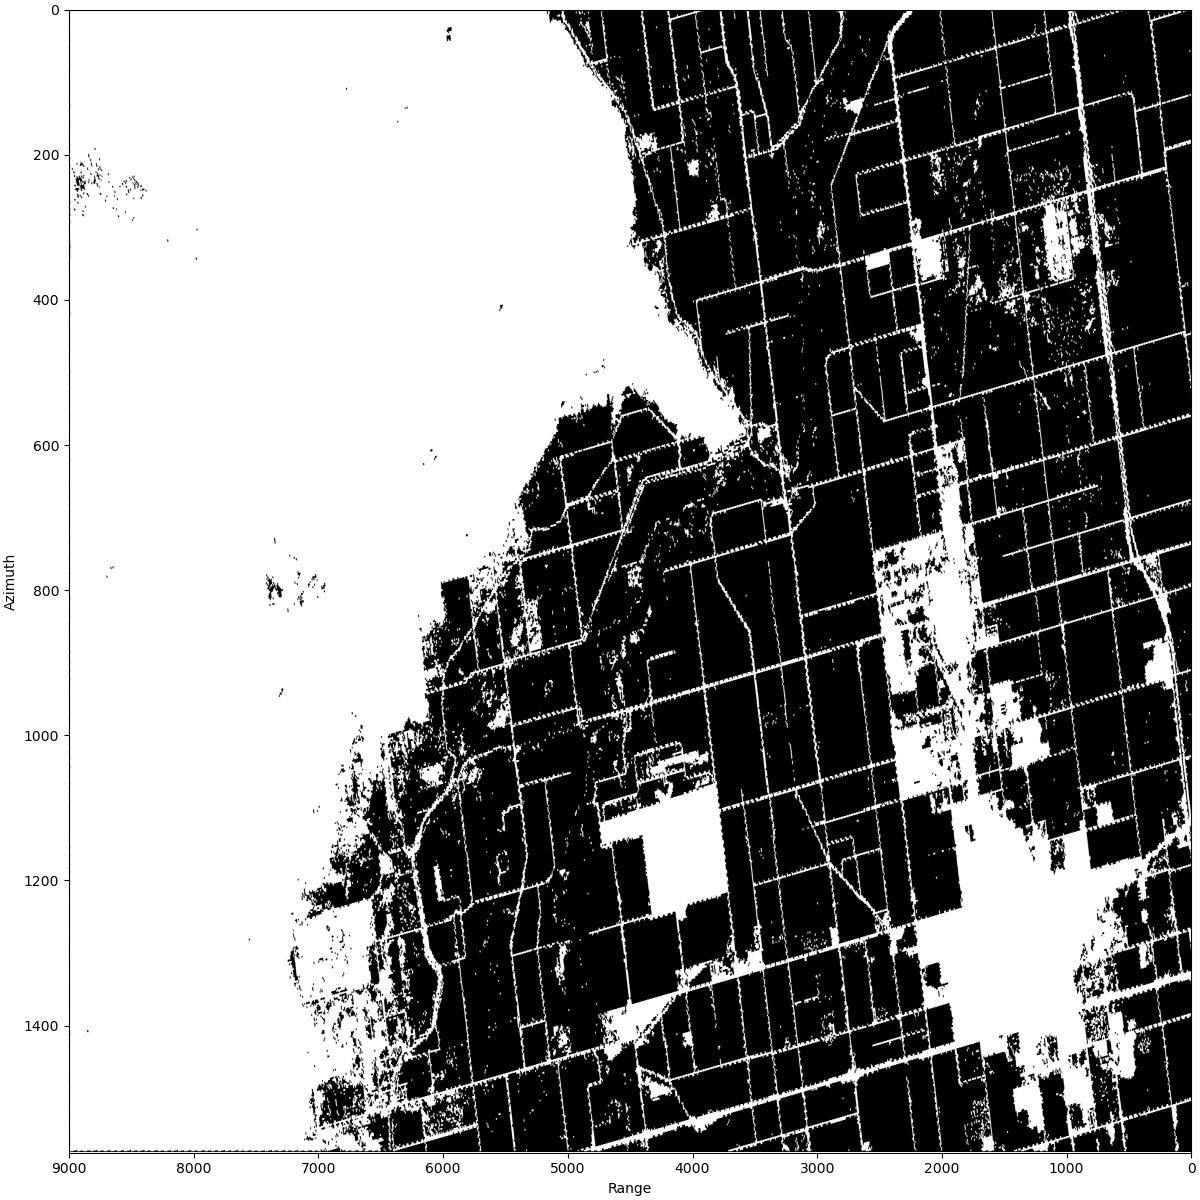

In [ ]:
# plot the roads mask very large and point-click along the boundary of the desert/fields 
#   red dots will appear where you have clicked. 
#   if you mess up, re-run this code cell to start over. 

# NOTE: 
# You must click the entire bounds of the polygon. In my case, the desert goes up to the left corners of my ROI, 
# so I must click those corners as points in my polygon shape to capture the entire desert. 

plt.figure(figsize=(12,12),constrained_layout=True)
plt.imshow(roads, cmap='gray', aspect='auto')
plt.xlim(dx,0); plt.ylim(dy,0)
plt.xlabel('Range'); plt.ylabel('Azimuth')
pts = []

plt.connect('button_press_event', on_click)
plt.show()

In [ ]:
# create a polygon object out of the points you clicked 

desert_poly = Polygon(pts)
print(desert_poly)

# NOTE
# if this prints "POLYGON EMPTY" that means you need to run the code cell above, click the points, then come back and run this. 

POLYGON ((5150.100761122482 15.169692348013541, 4621.651919835517 125.08010264927361, 4509.5567110776765 306.43227964635275, 4285.366293561995 372.37852582710866, 3820.971857279511 497.4016175447921, 3604.788240389389 588.0777060433318, 3812.9650566539503 605.9381477172865, 4461.515907324317 518.0098194762784, 5102.059957369122 557.8523432104851, 5462.365985519325 686.9970753144657, 6014.8352286829695 787.2903247143656, 6206.998443696411 862.8537317964818, 6719.433683732255 991.9984639004625, 7151.800917512499 1207.6976441166853, 7127.780515635819 1567.6542378533122, 5150.100761122482 15.169692348013541))


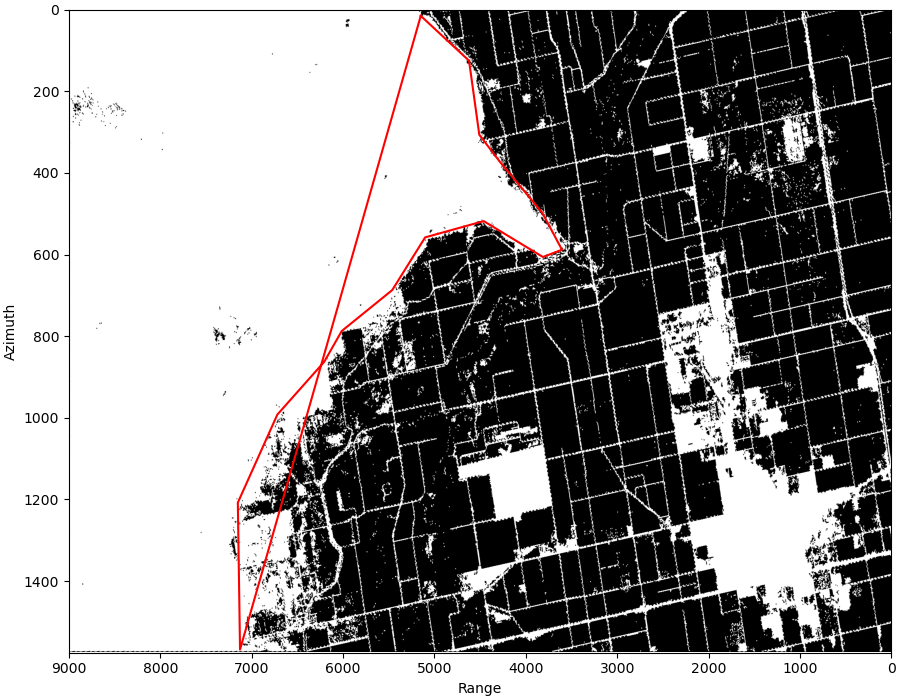

In [6]:
# plot the polygon you just made 

plt.figure(figsize=(9,7),constrained_layout=True)
plt.imshow(roads, cmap='gray', aspect='auto')
plt.xlim(dx,0); plt.ylim(dy,0)
plt.xlabel('Range'); plt.ylabel('Azimuth')
x,y = desert_poly.exterior.xy
plt.plot(x,y,'r-')
plt.show()

In [9]:
# Create vertex coordinates for each grid cell so that we can make a mask with each pixel having a value 1 or 0
# (<0,0> is at the top left of the grid in this system)
x, y = np.meshgrid(np.arange(dx), np.arange(dy))
x, y = x.flatten(), y.flatten()
points = np.vstack((x,y)).T

path = Path(pts)
grid = path.contains_points(points)
grid = grid.reshape((dy,dx))

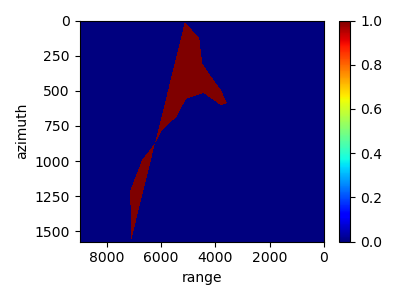

In [ ]:
# Plot the mask you have made to see if it's correct/what you wanted.

plt.figure(figsize=(4,3),tight_layout=True)
plt.imshow(grid,cmap='jet', interpolation='none',aspect='auto')
plt.xlim(dx, 0)
plt.xlabel('range'); plt.ylabel('azimuth')
plt.colorbar()
plt.show()

In [ ]:
# save the mask (0's and 1's) as a mask file. 

driver = gdal.GetDriverByName('ISCE')
fileName = 'no_desert.r4'
colds = driver.Create(fileName,dx,dy,1,gdal.GDT_Float32)
colds.GetRasterBand(1).WriteArray(grid)
colds=None
print('Saved.')